# Ejercicio Deber Análisis de datos clínicos para la detección de enfermedades cardíacas
<img src="img/Logo.jpeg" alt="logo itq" width="200">

**Nombre:** *Evelyn Lascano*<br>
**Fecha:** *05/05/2026*

# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
## Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [1]:
#Importación de librerias 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [4]:
#Configuración del entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/USUARIO/.kaggle"

In [6]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [7]:
#Descargamos el dataset
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown




  0%|          | 0.00/6.18k [00:00<?, ?B/s]
100%|##########| 6.18k/6.18k [00:00<00:00, 136kB/s]


In [9]:
#Descompriminos el archivo 
with zipfile.ZipFile("heart-disease-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [21]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/heart.csv")

In [22]:
#mostramos el conjunto de datos"
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Mantenemos estas columnas por estas razones:
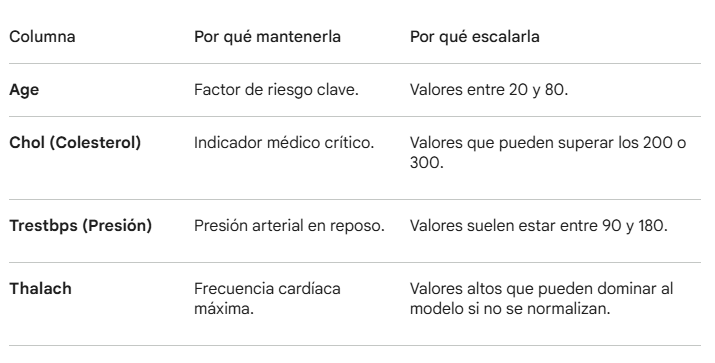 

In [23]:
#Eliminamos columnas innecesarias en la limpieza de datos 
# Definimos la lista de columnas que queremos eliminar para simplificar el dataset
cols_a_eliminar = ["cp", "fbs", "restecg", "exang", "oldpeak", "slope", "ca", "thal"]

# Verificamos si al menos una de esas columnas existe antes de intentar borrar
if any(col in df.columns for col in cols_a_eliminar):
    # Eliminamos solo las columnas que efectivamente estén presentes en el dataframe
    df = df.drop(columns=[col for col in cols_a_eliminar if col in df.columns])

# Verificamos qué columnas quedaron
print(df.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'thalach', 'target'], dtype='object')


In [24]:
#Mostramos los detalles de nuesto dataset
df.info()
#Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       1025 non-null   int64
 1   sex       1025 non-null   int64
 2   trestbps  1025 non-null   int64
 3   chol      1025 non-null   int64
 4   thalach   1025 non-null   int64
 5   target    1025 non-null   int64
dtypes: int64(6)
memory usage: 48.2 KB


age         0
sex         0
trestbps    0
chol        0
thalach     0
target      0
dtype: int64

In [26]:
#Separamos los datos de entrada con nuestra variable objetivo 
#Indica la presencia o ausencia de una enfermedad cardíaca en el paciente 0: Ausencia de enfermedad.1: Presencia de enfermedad.
x=df.drop(columns=['target'])
y=df['target']

In [27]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
x.describe()

,age,sex,trestbps,chol,thalach
count,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000
mean,54.434146,0.695610,131.611707,246.00000,149.114146
std,9.072290,0.460373,17.516718,51.59251,23.005724
min,29.000000,0.000000,94.000000,126.00000,71.000000
25%,48.000000,0.000000,120.000000,211.00000,132.000000
50%,56.000000,1.000000,130.000000,240.00000,152.000000
75%,61.000000,1.000000,140.000000,275.00000,166.000000
max,77.000000,1.000000,200.000000,564.00000,202.000000


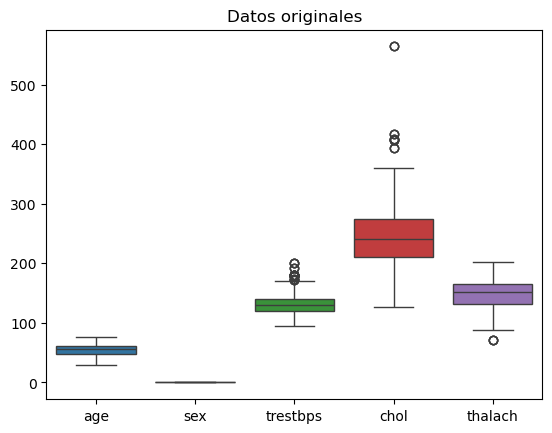

In [30]:
#Gráfica de los datos originales 
sns.boxplot(data=x)
plt.title("Datos originales")
plt.show()

**Interpretación de la imagen**
1. Diferencia de Escalas (El problema central)
El gráfico muestra claramente por qué necesitas la Normalización o Estandarización:
* Variables con valores altos: Las columnas chol (colesterol) y thalach (frecuencia cardíaca) tienen rangos que superan los 200 y 150 respectivamente.
* Variables con valores bajos: La variable age está concentrada entre 40 y 70 años, mientras que sex está casi pegada al cero (porque solo usa valores 0 y 1).
* Conclusión: Si no escalas estos datos, la computadora podría pensar que el chol es más importante que la age simplemente porque sus números son más grandes.

2. Identificación de Outliers (Valores Atípicos)
Los puntos negros que ves por encima de las cajas representan datos que se salen del comportamiento normal:

* Colesterol (chol): Es la variable con más valores atípicos. Hay un paciente con un valor cercano a 560, lo cual es extremadamente alto comparado con el promedio (la línea dentro de la caja roja).
* Presión Arterial (trestbps): También presenta varios puntos por encima de 180.
* Frecuencia Cardíaca (thalach): Tiene un valor atípico hacia abajo (un punto cerca de 70), lo que indica una frecuencia inusualmente baja para este grupo.

3. Distribución de los Datos
* La línea central dentro de cada caja es la mediana. Por ejemplo, en age, la mediana está cerca de los 55 años.
* El tamaño de la caja muestra dónde está el 50% de tus pacientes. En chol, la caja es más "alta", lo que indica que hay mucha variedad en los niveles de colesterol de las personas estudiadas.


In [31]:
#Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
x_norm=normalizer.fit_transform(x)
x_norm = pd.DataFrame(x_norm, columns=x.columns)
x_norm.head()

,age,sex,trestbps,chol,thalach
0,0.479167,1.0,0.292453,0.196347,0.740458
1,0.500000,1.0,0.433962,0.175799,0.641221
2,0.854167,1.0,0.481132,0.109589,0.412214
3,0.666667,1.0,0.509434,0.175799,0.687023
4,0.687500,0.0,0.415094,0.383562,0.267176


In [33]:
x_norm.describe()

,age,sex,trestbps,chol,thalach
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.529878,0.695610,0.354827,0.273973,0.596291
std,0.189006,0.460373,0.165252,0.117791,0.175616
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.245283,0.194064,0.465649
50%,0.562500,1.000000,0.339623,0.260274,0.618321
75%,0.666667,1.000000,0.433962,0.340183,0.725191
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
#Estaddarización 
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
x_std=standarizer.fit_transform(x)
x_std= pd.DataFrame(x_std, columns=x.columns)
x_std.head()

,age,sex,trestbps,chol,thalach
0,-0.268437,0.661504,-0.377636,-0.659332,0.821321
1,-0.158157,0.661504,0.479107,-0.833861,0.255968
2,1.716595,0.661504,0.764688,-1.396233,-1.048692
3,0.724079,0.661504,0.936037,-0.833861,0.516900
4,0.834359,-1.511706,0.364875,0.930822,-1.874977


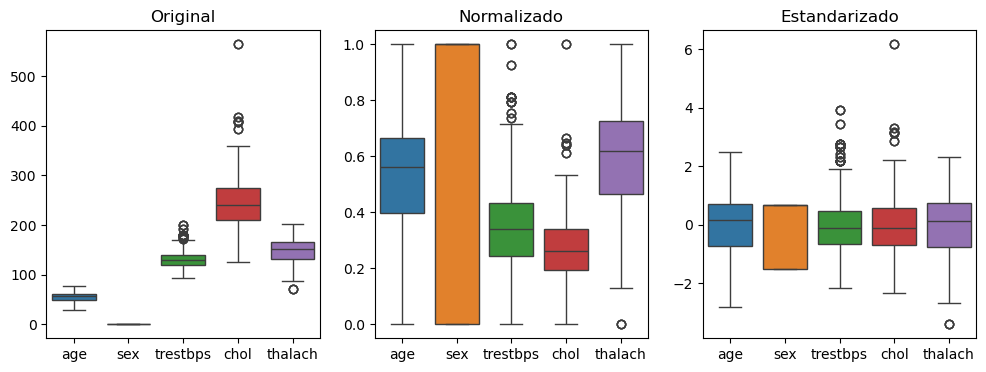

In [35]:
#Comporación visual
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=x)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=x_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=x_std)
plt.title("Estandarizado")

plt.show()

### Importancia del preprocesaminto en modelos de IA
La importancia del preprocesamiento en este ejercicio de enfermedades cardíacas radica en que los algoritmos de Machine Learning no pueden interpretar correctamente datos que tienen escalas y rangos tan disparatados sin ayuda previa.

Aquí tienes las razones clave por las que el preprocesamiento es vital en este dataset:

1. Nivelar la "Fuerza" de las Variables
Como se puede ver en el gráfico de cajas, hay variables como Chol (Colesterol) con valores que superan los 500, mientras que la Edad está cerca de 50.


El riesgo: Sin preprocesamiento, el modelo matemático pensará que el colesterol es 10 veces más importante que la edad simplemente porque el número es más grande.


La solución: Al normalizar (Min-Max), se obliga a que ambas variables compitan en igualdad de condiciones, generalmente en un rango de 0 a 1.

2. Manejo de Valores Atípicos (Outliers)
El gráfico mostró puntos negros extremos en el colesterol y la presión arterial.


Impacto: Estos valores pueden "jalar" el promedio y confundir al modelo, haciendo que las predicciones para pacientes normales sean erróneas.

**Importancia del preprocesamiento:** Aquí es donde decides usar Estandarización (Z-score), que es más robusta frente a estos valores extremos que la normalización simple.

3. Mejora el Desempeño de los Algoritmos
Muchos modelos de IA, como KNN (que mide distancias entre puntos) o la Regresión Logística, son extremadamente sensibles a la escala de los datos.

Si no preprocesas, el algoritmo calculará distancias basadas casi totalmente en las columnas con números altos, ignorando por completo el resto de la información médica.

4. Calidad y Ética del Modelo
En un contexto médico, un modelo que no ha sido preprocesado adecuadamente puede generar sesgos. Por ejemplo, podría ignorar factores de riesgo críticos solo porque sus unidades de medida son pequeñas, lo cual afectaría la confiabilidad de la detección temprana de enfermedades.

Resumen para tu informe:
En la fase de Preparación de Datos de la metodología CRISP-ML, el preprocesamiento es el filtro que transforma "datos brutos" en "información útil". Sin este paso, incluso el algoritmo más avanzado dará resultados incorrectos porque estaría trabajando con una visión distorsionada de la realidad médica.